In [2]:
import numpy as np
#if this fails, you need to put the case_studies.py file in the same folder
from case_studies import *

In [3]:
from scipy.optimize import minimize

#These are the example optimizers you should evaluate this week.
#These are optimizers implemented in scipy.
#they take as first 2 or 3 arguments the function f, its gradient df and sometimes its hessian Hf.
#the next parameters are all the same: x0 is the starting point, max_iterations the stopping criterion for iterations
#and epsilon the precision tolerance to be reached. 
#Note: epsilon is interpreted slightly differently across algorithms, and some algorithms might not reach the tolerance
#and stop early.
def scipy_bfgs(f,df,x0,max_iterations,epsilon):
    xs=[]
    grad_norms=[]
    def logging_f(x):
        xs.append(x)
        grad_norms.append(np.maximum(np.linalg.norm(df(x)),10**(-5)*epsilon))
        return f(x)
    minimize(logging_f, x0, method="BFGS", jac=df, tol=epsilon,options={'maxiter':max_iterations, 'gtol':epsilon})
    return np.array(xs), np.array(grad_norms)

def scipy_newton(f,df,Hf,x0,max_iterations,epsilon):
    xs=[]
    grad_norms=[]
    def logging_f(x):
        xs.append(x)
        grad_norms.append(np.maximum(np.linalg.norm(df(x)),10**(-5)*epsilon))
        return f(x)
    minimize(logging_f, x0, method="Newton-CG", jac=df, hess=Hf, tol=epsilon,options={'maxiter':max_iterations,'xtol':epsilon})
    return np.array(xs), np.array(grad_norms)

def scipy_trust_region(f,df,Hf,x0,max_iterations,epsilon):
    xs=[]
    grad_norms=[]
    def logging_f(x):
        xs.append(x)
        grad_norms.append(np.maximum(np.linalg.norm(df(x)),10**(-5)*epsilon))
        return f(x)
    minimize(logging_f, x0, method="trust-exact", jac=df, hess=Hf, tol=epsilon,options={'maxiter':max_iterations})
    return np.array(xs), np.array(grad_norms)

In [ ]:
#example usage of the algorithms
#the output is a list of points evaluated on the function as well as the gradient norms at that point
#this algorithms has the first three arguments functions for function value, gradient and Hessian.
#For the 5 functions, those are named f1-f5 etc and cna be found in the case_studies.py file
x0=np.ones(2)
xs,grad_norms = scipy_trust_region(f4,df4,Hf4,x0, 1000, 1.e-10)

#the optimal point for a given function and dimensionality is stored in the package as well for at least 15 decimals precision
optimal = x_opt("f4", 2)
print("final solution point:", xs[-1])
print("distance of x from optimum", np.linalg.norm(xs[-1]-optimal))
print("number of function evaluations:", len(grad_norms))
print("final function value:", f4(xs[-1]))
print("final gradient norm:", grad_norms[-1])



In [5]:
import numpy as np
import matplotlib.pyplot as plt

F1 = np.array(["f1", f1, df1, Hf1])
F2 = np.array(["f2", f2, df2, Hf2])
F3 = np.array(["f3", f3, df3, Hf3])
F4 = np.array(["f4", f4, df4, Hf4])
F5 = np.array(["f5", f5, df5, Hf5])
F = np.array([F1, F2, F3, F4, F5])

O1 = np.array(["scipy_bfgs", scipy_bfgs, 'blue'])
O2 = np.array(["scipy_newton", scipy_newton, 'orange'])
O3 = np.array(["scipy_trust_region", scipy_trust_region, 'green'])
O = np.array([O1, O2, O3])

In [ ]:
def plot_functions(F_list):
    # Generate grid for x and y
    limit = 10
    x_vals = np.linspace(-limit, limit, 100)
    y_vals = np.linspace(-limit, limit, 100)
    X, Y = np.meshgrid(x_vals, y_vals)
    
    # Determine the layout of subplots
    num_plots = len(F_list)
    cols = 3  # Number of columns in the subplot grid
    rows = (num_plots + cols - 1) // cols  # Number of rows needed

    fig = plt.figure(figsize=(16, 5*rows))  # Adjust figure size to fit all subplots

    for i, f in enumerate(F_list):
        # Compute Z values for the grid
        Z = np.array([f[1](np.array([[x], [y]])) for x, y in zip(np.ravel(X), np.ravel(Y))])
        Z = Z.reshape(X.shape)
        # Create subplot
        ax = fig.add_subplot(rows, cols, i + 1, projection='3d')
        # Plot the surface
        surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
        # Add title and labels
        ax.set_title(f"3D Plot of {f[0]}")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_zlabel(f"{f[0]}([x,y])")

    # Adjust layout for better appearance
    # plt.tight_layout()
    plt.show()

plot_functions(F)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (2, 9) + inhomogeneous part.

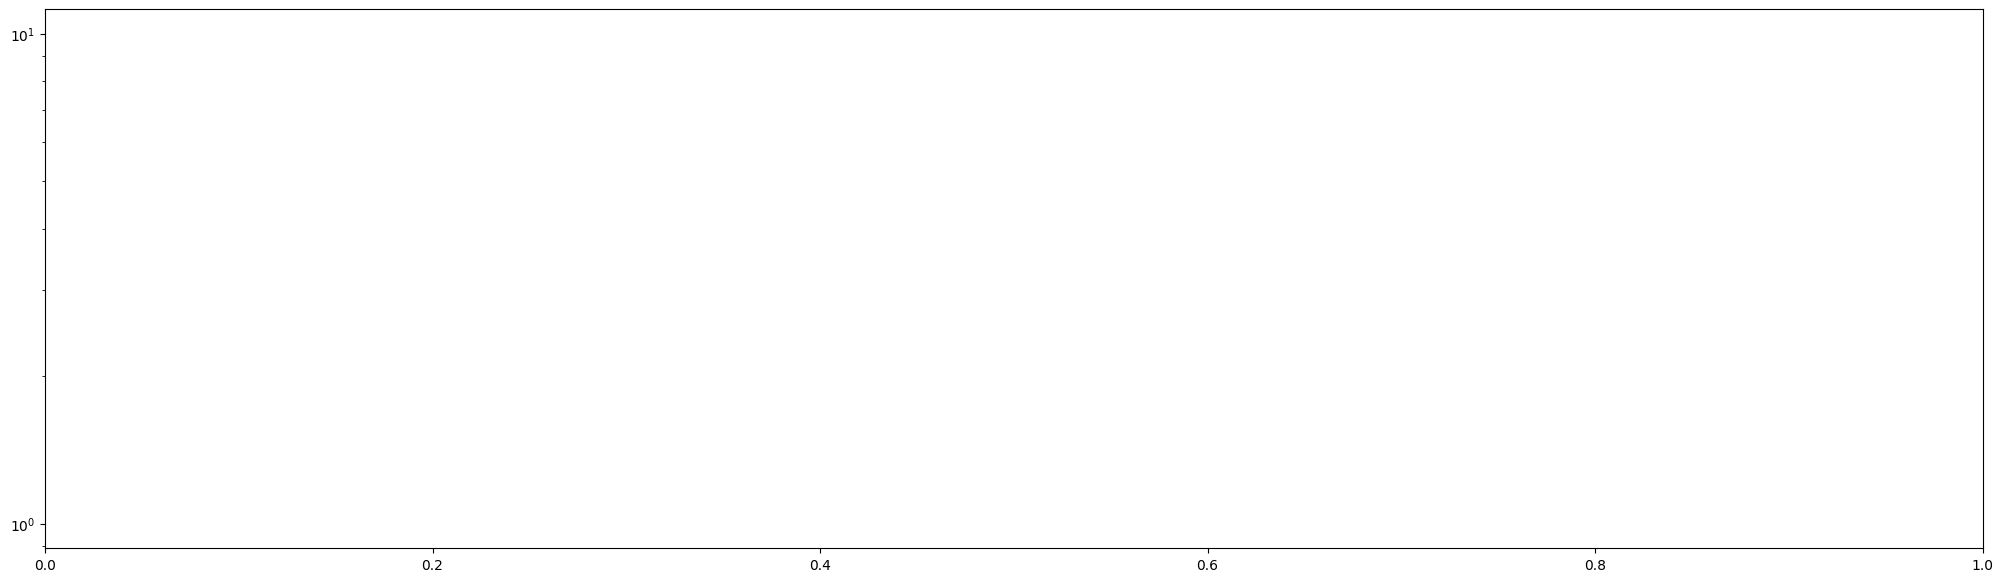

In [82]:
def plot_optimizers(F, O, xs):
    line_styles = ['-', '--', ':', '-.']
    
    for idx, f in enumerate(F, 1):
        plt.figure(figsize=(25, 7))
        plt.yscale("log")
        optimal = x_opt(f[0], 2)
        t = 0
        for o in O:
            for i, x0 in enumerate(xs):
                max_iterations, epsilon = 1000, 1.e-10
                if (o[1] == scipy_bfgs):
                    xk = o[1](f[1],f[2],x0,max_iterations,epsilon)
                else:
                    xk = o[1](f[1],f[2],f[3],x0,max_iterations,epsilon)
                t = (len(xk) if t < len(xk) else t)
                N = [np.linalg.norm(v, ord=2) for v in xk-np.full_like(xk, optimal)]
                label = f"{o[0]}: {len(xk)}, {np.array2string(x0, precision=2)} - {xk[-1]}"
                plt.plot(range(0,len(xk)), N, 
                        label=label, 
                        color=o[2], 
                        linestyle=line_styles[i % len(line_styles)])
        
        plt.legend(loc='upper right', fontsize=12)    
        plt.title(f"{f[0]} optimum convergence, with x* = {optimal}", fontsize=24)
        plt.xlabel("Step", fontsize=20)
        plt.ylabel("$||x_k - x*||_2$", fontsize=20)
        
        # Show only 10 ticks on x-axis
        num_ticks = 10
        step = max(t // num_ticks, 1)
        xticks_positions = list(range(0, t, step))
        if t-1 not in xticks_positions:
            xticks_positions.append(t-1)
        plt.xticks(xticks_positions, xticks_positions, fontsize=16)
        
        # Reduce y-axis grid lines
        plt.gca().yaxis.set_major_locator(plt.LogLocator(numticks=10))
        plt.yticks(fontsize=16)
        
        # Only show major grid lines
        plt.grid(True, which='major', linestyle='--', alpha=0.7)
        plt.grid(False, which='minor')
        
        plt.savefig(f'{idx}.png', bbox_inches='tight', dpi=300)
        plt.close()

xs = []
for _ in range(4):
    # xs.append(np.random.normal(0, 10, size=2))
    xs.append(np.random.uniform(-50, 50+1, size=2))  
    # xs.append(np.random.randint(-10, 10+1, size=2))  
    np.ones(2)  

plot_optimizers(F, O, xs)

In [ ]:
import time
import seaborn as sns
import pandas as pd

def measure_runtime_with_trials(F, O, x0, n_trials=5, max_iterations=1000, epsilon=1.e-10):
    results = {
        'Function': [],
        'Optimizer': [],
        'Runtime (s)': [],
        'Trial': []
    }
    
    for f in F:
        for o in O:
            for trial in range(n_trials):
                start_time = time.time()
                
                if o[0] == 'scipy_bfgs':
                    o[1](f[1], f[2], x0, max_iterations, epsilon)
                else:
                    o[1](f[1], f[2], f[3], x0, max_iterations, epsilon)
                
                runtime = time.time() - start_time
                
                results['Function'].append(f[0])
                results['Optimizer'].append(o[0])
                results['Runtime (s)'].append(runtime)
                results['Trial'].append(trial)
    
    return pd.DataFrame(results)

# Measure runtime with multiple trials
runtime_df = measure_runtime_with_trials(F, O, x0, n_trials=5)

# Create bar plot with error bars
plt.figure(figsize=(12, 4))
plt.yscale("log")
sns.barplot(data=runtime_df, x='Function', y='Runtime (s)', 
            hue='Optimizer', ci='sd')
plt.tight_layout()
plt.savefig("k.png")

# Display average runtimes
print("\nAverage Runtime Results (seconds):")
pivot_table = runtime_df.groupby(['Function', 'Optimizer'])['Runtime (s)'].agg(['mean', 'std']).round(4)
print(pivot_table)

In [ ]:
# https://en.wikipedia.org/wiki/Wolfe_conditions For c_1 and c_2 choice
#def wolfe_line_search(f, df, x, p, c1=1e-4, c2=0.9, max_iter=1000):
#    a = 1.0
#    fx = f(x)
#    grad_x = df(x)
#    for _ in range(max_iter):
#        new_x = x + a * p
#        if f(new_x) > fx + c1 * a * np.dot(p, grad_x):
#            a *= 0.5  # Reduce step size
#        elif np.dot(p, df(new_x)) < c2 * np.dot(p, grad_x):
#            a *= 2.0  # Increase step size
#        else:
#            break
#    return a

def is_pos_def(H):
    return np.all(np.linalg.eigvals(H) > 0)

def backtrack(f, df, x, p, alpha_init=1.0, rho=0.5, c1=1e-4):
    fx = f(x)
    grad_x = df(x)
    alpha = alpha_init
    while f(x + alpha * p) > fx + c1 * alpha * np.dot(grad_x, p):
        alpha *= rho
    return alpha

def steepest_descent(f, df, x0, c1=1e-6, rho=0.5, max_iter=1000):
    x = x0.copy()
    beta = 1.0
    xs=[]
    for _ in range(max_iter):
        p = -df(x) # p_k = −∇f(x_k);
        alpha = backtrack(f, df, x, p, beta, rho=rho, c1=c1) # α_k = backtrack(x_k,p_k,β_k,c_1,ρ);
        x = x + alpha * p # x_{k+1} = x_k + α_k p_k;
        beta = alpha / rho # β_{k+1} = α_k / ρ;
        xs.append(x)
    return x, xs

def newtons_method(f, df, Hf, x0, c1=1e-6, rho=0.5, max_iter=1000):
    x = x0.copy()
    xs=[]
    for _ in range(max_iter):
        H = Hf(x)
        if is_pos_def(Hf(x)): # if ∇^2 f(x_k) is positive definite then
            p = np.dot(-np.linalg.inv(Hf(x)), df(x)) # p_k = (−∇^2 f(x_k))^{−1} ∇f(x_k)
        else:
            e_values, e_vectors = np.linalg.eigh(Hf(x)) # Compute eigenvalues λ_i and eigenvector v_i of ∇^2 f(xk);
            new_H = np.zeros_like(H)
            for i in range(len(e_values)): # sum_{i=1}^N
                new_H += (1 / np.abs(e_values[i])) * np.dot(e_vectors[:, i], e_vectors[:, i]) # H=1/|λ_i| * v_i.v_i^T
            p = -new_H @ df(x) # p_k = −H^∇ f(x_k)
        a = backtrack(f, df, x, p, 1.0, rho, c1) # α_k = backtrack(x_k,p_k,1.0,c1,ρ);
        x = x + a * p # x_{k+1} = x_k + α_k p_k;
        xs.append(x)
    return x, xs

x0_f1 = np.random.randn(5)
x0_f2 = np.random.randn(2)
x0_f3 = np.random.randn(5)
x0_f4 = np.random.randn(5)
x0_f5 = np.random.randn(5)

print("Steepest Descent Results:")
print("f1:", steepest_descent(f1, df1, x0_f1)[0])
print("f2:", steepest_descent(f2, df2, x0_f2)[0])
print("f3:", steepest_descent(f3, df3, x0_f3)[0])
print("f4:", steepest_descent(f4, df4, x0_f4)[0])
print("f5:", steepest_descent(f5, df5, x0_f5)[0])

# Running Newton's Method
print("\nNewton's Method Results:")
print("f1:", newtons_method(f1, df1, Hf1, x0_f1)[0])
print("f2:", newtons_method(f2, df2, Hf2, x0_f2)[0])
print("f3:", newtons_method(f3, df3, Hf3, x0_f3)[0])
print("f4:", newtons_method(f4, df4, Hf4, x0_f4)[0])
print("f5:", newtons_method(f5, df5, Hf5, x0_f5)[0])

Steepest Descent Results:
f1: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
f2: [0.81101263 0.65577302]
f3: [-7.44363476e-002  5.35580094e-006  1.35213122e-032  4.33608803e-239
  7.61692254e-005]
f4: [0.00190933 0.00190933 0.00190933 0.00190933 0.00190933]
f5: [ 0.00000000e+000 -1.16708878e-216 -1.42891633e-162 -3.15282048e-130
  1.32746213e-108]

Newton's Method Results:
f1: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
f2: [1. 1.]
f3: [-1.16401659  1.20968405  0.82927598 -0.08295081 -0.01711157]
f4: [0.00190933 0.00190933 0.00190933 0.00190933 0.00190933]
f5: [ 0.00000000e+000 -9.52059001e-217 -1.36187812e-162  3.36555916e-130
  1.02373204e-108]


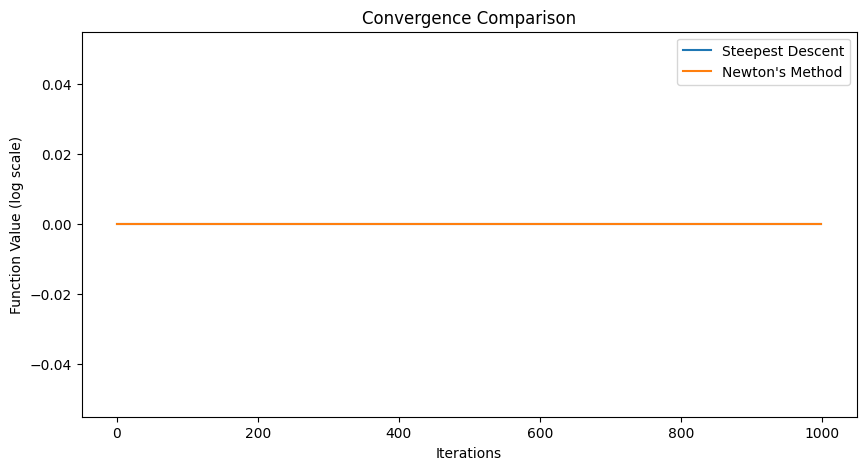

In [75]:
def plot_convergence(histories, labels):
    plt.figure(figsize=(10, 5))
    for hist, label in zip(histories, labels):
        f_vals = [h[1] for h in hist]
        plt.plot(f_vals, label=label)
    plt.xlabel("Iterations")
    plt.ylabel("Function Value (log scale)")
    plt.legend()
    plt.title("Convergence Comparison")
    plt.show()

# Example functions
def f1(x): return np.sum(x**2)
def df1(x): return 2*x
def Hf1(x): return 2*np.eye(len(x))

x0 = np.random.randn(5)
res_sd, hist_sd = steepest_descent(f1, df1, x0)
res_nm, hist_nm = newtons_method(f1, df1, Hf1, x0)

plot_convergence([hist_sd, hist_nm], ["Steepest Descent", "Newton's Method"])

# Theory task 2

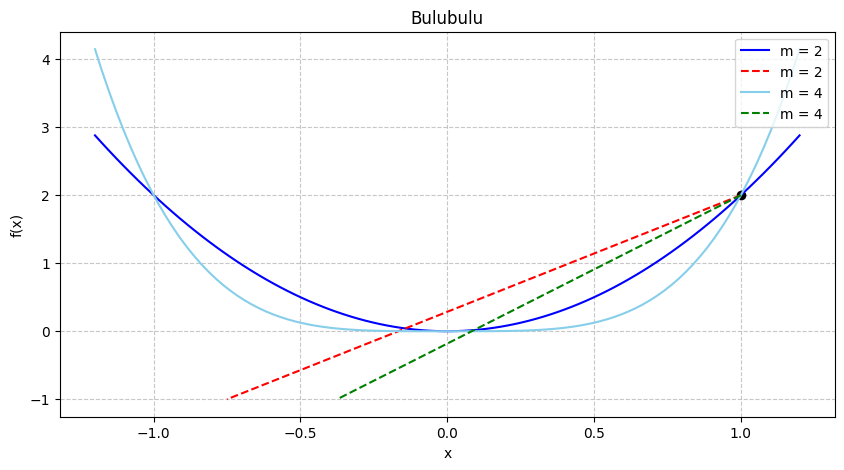

In [51]:
import numpy as np
import matplotlib.pyplot as plt

c1 = 1/3
a = 2

def Blue(x,a,m):
    return a*(x**m)

def Red(x,a,m,c1):
    #return a*(x**m) + c1 * (1-m) * (a**3) * (m**3) * (x**(3*m-4))
    return -1 / (c1*a*m*(x**(m-1))) 


line_styles = ['-', '--', ':', '-.']
    
plt.figure(figsize=(10, 5))
X = np.linspace(-1.2, 1.2, 100)
plt.plot(1, Blue(1,a,2), 
        label="", 
        color="black", 
        marker='o') 
plt.plot(X, [Blue(x,a,2) for x in X], 
        label="m = 2", 
        color="blue", 
        linestyle="-")  
plt.plot((1, Red(1,a,2,c1)), (Blue(1,a,2), -1), 
        label="m = 2", 
        color="red", 
        linestyle="--")
plt.plot(X, [Blue(x,a,4) for x in X], 
        label="m = 4", 
        color="skyblue", 
        linestyle="-")   
plt.plot((1, Red(1,a,4,c1)), (Blue(1,a,4), -1), 
        label="m = 4", 
        color="green", 
        linestyle="--")         
plt.legend(loc='upper right')#, fontsize=12)    
plt.title(f"Bulubulu")#, fontsize=24)
plt.xlabel("x")#, fontsize=20)
plt.ylabel("f(x)")#, fontsize=20)
plt.grid(True, which='major', linestyle='--', alpha=0.7)
#plt.grid(False, which='minor')
plt.show()